# Basic comparsion of naive and fast convolution

In [1]:
import numpy as np
import sympy as sy
from scipy import signal
from scipy import datasets
from matplotlib import pyplot as plt

In [2]:
from naive_convolve import naive_convolve
from fast_convolution import c3x3_5m20a9e
from utils import plot_pdf, symmetrical_cyclic_convolution

In [68]:
from sympy import init_printing
init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [69]:
[0, 1, 3]

Lets do a really basic test to compare naive with fast convolution
The input feature will be a simple 5x5 matrix and the output will be a 3x3 matrix

In [4]:
feature = np.arange(5*5).reshape(5, 5)
feature

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24]])

In [5]:
weight = np.array([
    [ 1, 0, 1],
    [ 2, 1, 2],
    [ 1, 2, 1],
])
weight

array([[1, 0, 1],
       [2, 1, 2],
       [1, 2, 1]])

In [6]:
np.fliplr(weight)

array([[1, 0, 1],
       [2, 1, 2],
       [1, 2, 1]])

Convolution with no paddin and stride 1
Using convolve2d from scipy, our gold method, it's necessary to reverse the weights to get same result of naive and fast convolution

In [7]:
weight_reversed = weight[::-1, ::-1]
weight_reversed

array([[1, 2, 1],
       [2, 1, 2],
       [1, 0, 1]])

In [8]:
output = signal.convolve2d(feature, weight_reversed, mode='valid')
output

array([[ 76,  87,  98],
       [131, 142, 153],
       [186, 197, 208]])

Running naive convolution
9 multiplications and 8 aditions per output scalar

In [9]:
output_naive = naive_convolve(feature, weight)
output_naive

array([[ 76,  87,  98],
       [131, 142, 153],
       [186, 197, 208]])

In [10]:
np.all(output == output_naive)

True

Fast convolution need to reverse the features order

In [11]:
fv = list(reversed(feature[0].tolist()))
fv

Init Tap filter from fast 1d convolution method with 5 multiplications, 20 aditions and 9 extras operations, 5 input and 3 output per batch

In [12]:
fast_conv = c3x3_5m20a9e(weight[0].tolist())

The tap filter work in batch mode and the output is reversed

In [13]:
fast_conv(fv[2:] + [0, 0])

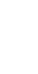

In [52]:
fast_conv([0] + fv[:-1])

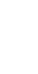

In [44]:
import IPython.display as disp
disp.display(fast_conv([0] + fv[:-1]))

How join multiple 1d convolution in one 2d convolution

In [15]:
c0 = np.convolve(feature[0], weight[0])
c0

array([0, 1, 2, 4, 6, 3, 4])

In [16]:
c1 = np.convolve(feature[1], weight[1])
c1

array([10, 17, 30, 35, 40, 25, 18])

In [17]:
c2 = np.convolve(feature[2], weight[2])
c2

array([10, 31, 44, 48, 52, 41, 14])

In [18]:
c0+c1+c2

array([20, 49, 76, 87, 98, 69, 36])

Run one fast convolution for each 1d kernel

In [19]:
fast_conv0 = c3x3_5m20a9e(weight[0].tolist())
out0 = [fast_conv0(feature[i]).flat() for i in range(0, 3)]
out0

In [20]:
fast_conv1 = c3x3_5m20a9e(weight[1].tolist())
out1 = [fast_conv1(feature[i+1]).flat() for i in range(0, 3)]
out1

In [21]:
fast_conv2 = c3x3_5m20a9e(weight[2].tolist())
out2 = [fast_conv2(feature[i+2]).flat() for i in range(0, 3)]
out2

Sum results in the first dimension

In [22]:
output_fast = np.sum([out0, out1, out2], axis=0)
output_fast

array([[76, 87, 98],
       [131, 142, 153],
       [186, 197, 208]], dtype=object)

In [23]:
np.all(output_fast == output_naive)

True

Camparing how much operations are used in naive and fast method

Output Size

In [24]:
size = output.size
size

Naive: total of multiplications

In [25]:
size * 9

Naive: total of additions

In [26]:
size * 8

Fast: total of multiplications

In [27]:
size * 5

Fast: additions for each batch processed

In [28]:
add0 = size * 20
add0

Fast: additions to join batches

In [29]:
add1 = size * 2
add1

Fast: Total of additions

In [30]:
add0 + add1

Fast: total of extra operations - bit shifts and etc

In [31]:
size * 9